In [189]:
!pip install pvlib

In [190]:
width_m, depth_m, height_m = 25, 25, 81
window_wall_ratio = 0.90
T_indoor_C = 22
U_wall = 0.25
U_roof = 0.20
U_glass = 1.4
ACH = 0.8
air_density = 1.2
air_cp = 1005
n_people = 300
person_heat_W = 200
light_total = 7
n_lights = 6500
electricity_price_eur_kwh = 0.22
cooling_cop = 2.5
heating_cop = 3.5

In [191]:
footprint_m2 = width_m * depth_m
facade_area_by_orientation = {
    "North": width_m * height_m, "South": width_m * height_m,
    "East": depth_m * height_m, "West": depth_m * height_m,
}
glazing_area_by_orientation = {k: v * window_wall_ratio for k, v in facade_area_by_orientation.items()}
glazing_area = sum(glazing_area_by_orientation.values())
wall_area = 2 * (width_m + depth_m) * height_m * (1 - window_wall_ratio)
roof_area = footprint_m2
volume_m3 = footprint_m2 * height_m

Q_people = n_people * person_heat_W
Q_light = light_total * n_lights

print(f"Glazing area: {glazing_area:.0f} m2")
print(f"Q_people: {Q_people:.0f} W, Q_light: {Q_light:.0f} W")

Glazing area: 7290 m2
Q_people: 60000 W, Q_light: 45500 W


In [192]:
import numpy as np

tau_e_0 = {0: 0.450, 25: 0.416, 50: 0.364, 100: 0.213}
p = 2

def karlsson_roos_tau(theta_deg, tau0, q, p=2):
    if theta_deg >= 90:
        return 0.0
    z = theta_deg / 90
    a = 8
    b = 0.25 / q
    c = 1 - a - b
    alpha = 5.2 + 0.7*q
    beta = 2
    gamma = (5.26 + 0.06*p) + (0.73 + 0.14*q)
    factor = 1 - a*(z**alpha) - b*(z**beta) - c*(z**gamma)
    return tau0 * factor

q_guess = {0: 2.19, 25: 2.15, 50: 2.24, 100: 3.92}

In [193]:
from scipy.integrate import quad

def tau_e_diffuse(state):
    tau0 = tau_e_0[state]
    q = q_guess[state]
    def integrand(phi_rad):
        phi_deg = np.degrees(phi_rad)
        return karlsson_roos_tau(phi_deg, tau0, q, p) * np.cos(phi_rad) * np.sin(phi_rad)
    integral, _ = quad(integrand, 0, np.pi/2)
    return 2 * integral

tau_e_dif = {state: tau_e_diffuse(state) for state in [0, 25, 50, 100]}

In [194]:
# Piccolo, Marino, Nucara, Pietrafesa (2018), Energy & Buildings 165, 390-398, Tabela 2
rho_e_light = 0.099
rho_e_dark = 0.083
rho_e = {state: rho_e_light + (state/100)*(rho_e_dark - rho_e_light) for state in [0, 25, 50, 100]}

In [195]:
Fi = 0.258

def alpha_e_direct(theta_deg, state):
    tau = karlsson_roos_tau(theta_deg, tau_e_0[state], q_guess[state], p=p)
    return 1 - tau - rho_e[state]

def qi_direct(theta_deg, state):
    return Fi * alpha_e_direct(theta_deg, state)

def g_direct(theta_deg, state):
    tau = karlsson_roos_tau(theta_deg, tau_e_0[state], q_guess[state], p=p)
    return tau + qi_direct(theta_deg, state)

In [196]:
def alpha_e_diffuse(state):
    return 1 - tau_e_dif[state] - rho_e[state]

def qi_diffuse(state):
    return Fi * alpha_e_diffuse(state)

def g_diffuse(state):
    return tau_e_dif[state] + qi_diffuse(state)

g_dif = {state: g_diffuse(state) for state in [0, 25, 50, 100]}

In [197]:
import pvlib

FILEPATH_EPW = "SVN_LJ_Ljubljana-Bezigrad.140150_TMYx.2007-2021.epw"
epw_data, epw_meta = pvlib.iotools.read_epw(FILEPATH_EPW)
LAT = epw_meta['latitude']
LON = epw_meta['longitude']
solar_position = pvlib.solarposition.get_solarposition(epw_data.index, LAT, LON)
print(f"Lokacija: {epw_meta['city']}, {len(epw_data)} ur")

Lokacija: Ljubljana-Bezigrad, 8760 ur


In [198]:
dT_hourly = epw_data['temp_air'] - T_indoor_C

print("Statistika urnega dT (stopinje C):")
print(f"  Min (najbolj mrzlo): {dT_hourly.min():.1f}")
print(f"  Max (najbolj vroce): {dT_hourly.max():.1f}")
print(f"  Povprecje: {dT_hourly.mean():.1f}")

Statistika urnega dT (stopinje C):
  Min (najbolj mrzlo): -30.5
  Max (najbolj vroce): 13.2
  Povprecje: -10.6


In [199]:
Q_wall_hourly = U_wall * wall_area * dT_hourly
Q_roof_hourly = U_roof * roof_area * dT_hourly
Q_glass_cond_hourly = U_glass * glazing_area * dT_hourly
Q_vent_hourly = ACH * volume_m3 * air_density * air_cp * dT_hourly / 3600

Q_envelope_hourly = Q_wall_hourly + Q_roof_hourly + Q_glass_cond_hourly + Q_vent_hourly

print(f"Q_envelope, povprecje cez leto: {Q_envelope_hourly.mean():.0f} W")
print(f"Q_envelope, min (poletje): {Q_envelope_hourly.min():.0f} W")
print(f"Q_envelope, max (zima): {Q_envelope_hourly.max():.0f} W")

Q_envelope, povprecje cez leto: -254661 W
Q_envelope, min (poletje): -735080 W
Q_envelope, max (zima): 318133 W


In [200]:
facade_azimuths = {"North": 0, "East": 90, "South": 180, "West": 270}
dni_extra = pvlib.irradiance.get_extra_radiation(epw_data.index)

facade_irradiance = {}
for facade, az in facade_azimuths.items():
    total_irrad = pvlib.irradiance.get_total_irradiance(
        surface_tilt=90, surface_azimuth=az,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni=epw_data['dni'], ghi=epw_data['ghi'], dhi=epw_data['dhi'],
        dni_extra=dni_extra, model='perez'
    )
    aoi = pvlib.irradiance.aoi(
        surface_tilt=90, surface_azimuth=az,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth']
    )
    facade_irradiance[facade] = {
        'aoi': aoi,
        'poa_direct': total_irrad['poa_direct'].clip(lower=0),
        'poa_diffuse_total': (total_irrad['poa_diffuse'] + total_irrad.get('poa_ground_diffuse', 0)).clip(lower=0),
    }

In [201]:
q_sol_results = {}
for state in [0, 25, 50, 100]:
    q_sol_by_facade = {}
    for facade in facade_azimuths:
        aoi = facade_irradiance[facade]['aoi']
        poa_direct = facade_irradiance[facade]['poa_direct']
        poa_diffuse = facade_irradiance[facade]['poa_diffuse_total']
        g_direct_hourly = aoi.apply(lambda theta: g_direct(theta, state) if theta < 90 else 0)
        q_sol_by_facade[facade] = g_direct_hourly * poa_direct + g_dif[state] * poa_diffuse
    q_sol_results[state] = q_sol_by_facade

In [202]:
power_density_by_state = {0: 1.00, 25: 0.75, 50: 0.50, 100: 0.00}

In [203]:
percent_time_at_0 = 10
percent_time_at_25 = 25
percent_time_at_50 = 25
percent_time_at_100 = 40
assert percent_time_at_0+percent_time_at_25+percent_time_at_50+percent_time_at_100 == 100

activation_mix = {
    0: percent_time_at_0/100, 25: percent_time_at_25/100,
    50: percent_time_at_50/100, 100: percent_time_at_100/100,
}
print("Aktivacijska mesanica (ciljna):", activation_mix)

Aktivacijska mesanica (ciljna): {0: 0.1, 25: 0.25, 50: 0.25, 100: 0.4}


In [204]:
import pandas as pd

def rank_facade_activation(facade, percent_100, percent_50, percent_25):
    facade_intensity = facade_irradiance[facade]['poa_direct'] + facade_irradiance[facade]['poa_diffuse_total']
    ranked = facade_intensity.sort_values(ascending=False)

    n_hours = len(ranked)
    n_100 = int(round(n_hours * (percent_100/100)))
    n_50 = int(round(n_hours * (percent_50/100)))
    n_25 = int(round(n_hours * (percent_25/100)))

    idx_100 = ranked.iloc[:n_100].index
    idx_50 = ranked.iloc[n_100:n_100+n_50].index
    idx_25 = ranked.iloc[n_100+n_50:n_100+n_50+n_25].index
    idx_0 = ranked.iloc[n_100+n_50+n_25:].index

    state_by_hour = pd.Series(index=epw_data.index, dtype=int)
    state_by_hour.loc[idx_100] = 100
    state_by_hour.loc[idx_50] = 50
    state_by_hour.loc[idx_25] = 25
    state_by_hour.loc[idx_0] = 0
    return state_by_hour

facade_state_schedule = {
    facade: rank_facade_activation(facade, percent_time_at_100, percent_time_at_50, percent_time_at_25)
    for facade in facade_azimuths
}

In [205]:
baseline_solar_hourly = sum(q_sol_results[0][facade] * glazing_area_by_orientation[facade] for facade in facade_azimuths)

weighted_solar_hourly = pd.Series(0.0, index=epw_data.index)
for facade in facade_azimuths:
    for state in [0, 25, 50, 100]:
        mask = (facade_state_schedule[facade] == state)
        contribution = q_sol_results[state][facade] * glazing_area_by_orientation[facade]
        weighted_solar_hourly[mask] += contribution[mask]

occupied_hours_mask = (epw_data.index.hour >= 7) & (epw_data.index.hour < 22)
Q_people_light_hourly = (Q_people + Q_light) * (occupied_hours_mask.astype(float)*1.0 + (~occupied_hours_mask).astype(float)*0.35)

# ZDAJ pravilno vkljucuje URNI Q_envelope (prava zunanja temperatura)
Q_internal_hourly = Q_people_light_hourly + Q_envelope_hourly

In [206]:
def annual_energy_breakdown(solar_hourly):
    total_load_hourly = Q_internal_hourly + solar_hourly

    cooling_wh_hourly = total_load_hourly.clip(lower=0)
    cooling_kwh_annual = cooling_wh_hourly.sum() / 1000
    cooling_electricity_kwh = cooling_kwh_annual / cooling_cop

    heating_wh_hourly = (-total_load_hourly).clip(lower=0)
    heating_kwh_annual = heating_wh_hourly.sum() / 1000
    heating_electricity_kwh = heating_kwh_annual / heating_cop

    return {
        'cooling_electricity_kwh': cooling_electricity_kwh,
        'cooling_cost_eur': cooling_electricity_kwh * electricity_price_eur_kwh,
        'heating_electricity_kwh': heating_electricity_kwh,
        'heating_cost_eur': heating_electricity_kwh * electricity_price_eur_kwh,
    }

baseline_breakdown = annual_energy_breakdown(baseline_solar_hourly)
weighted_breakdown = annual_energy_breakdown(weighted_solar_hourly)

cooling_savings_eur = baseline_breakdown['cooling_cost_eur'] - weighted_breakdown['cooling_cost_eur']
heating_extra_cost_eur = weighted_breakdown['heating_cost_eur'] - baseline_breakdown['heating_cost_eur']

print(f"Prihranek pri hlajenju: {cooling_savings_eur:,.0f} EUR/leto")
print(f"Dodaten strosek ogrevanja: {heating_extra_cost_eur:,.0f} EUR/leto")
print(f"NETO prihranek (energija): {cooling_savings_eur - heating_extra_cost_eur:,.0f} EUR/leto")

Prihranek pri hlajenju: 83,391 EUR/leto
Dodaten strosek ogrevanja: 1,407 EUR/leto
NETO prihranek (energija): 81,985 EUR/leto


In [207]:
weighted_power_density = sum(power_density_by_state[state]*activation_mix[state] for state in [0,25,50,100])
window_operating_kwh = weighted_power_density * glazing_area * len(epw_data) / 1000
window_operating_cost_eur = window_operating_kwh * electricity_price_eur_kwh
print(f"Strosek delovanja stekla: {window_operating_cost_eur:,.0f} EUR/leto")

Strosek delovanja stekla: 5,795 EUR/leto


In [208]:
net_annual_savings_eur = (cooling_savings_eur - heating_extra_cost_eur) - window_operating_cost_eur

cost_standard_glass_eur_m2 = 400
cost_spd_glass_eur_m2 = 600
curtain_blackout_eur_m2 = 60
curtain_normal_eur_m2 = 10
fixed_installation_cost_eur = 10000

cost_scenario_A_eur_m2 = cost_standard_glass_eur_m2 + curtain_blackout_eur_m2
cost_scenario_B_eur_m2 = cost_spd_glass_eur_m2 + curtain_normal_eur_m2
extra_cost_per_m2 = cost_scenario_B_eur_m2 - cost_scenario_A_eur_m2
total_extra_investment_eur = extra_cost_per_m2 * glazing_area + fixed_installation_cost_eur

print(f"NETO letni prihranek: {net_annual_savings_eur:,.0f} EUR")
print(f"Neto investicija: {total_extra_investment_eur:,.0f} EUR")

if total_extra_investment_eur > 0 and net_annual_savings_eur > 0:
    payback = total_extra_investment_eur / net_annual_savings_eur
    print(f"Doba amortizacije: {payback:.1f} let")
elif total_extra_investment_eur <= 0:
    print("EC resitev je net cenejsa -- takojsen prihranek.")
else:
    print("Investicija se ne povrne skozi energetske prihranke.")

NETO letni prihranek: 76,189 EUR
Neto investicija: 1,103,500 EUR
Doba amortizacije: 14.5 let


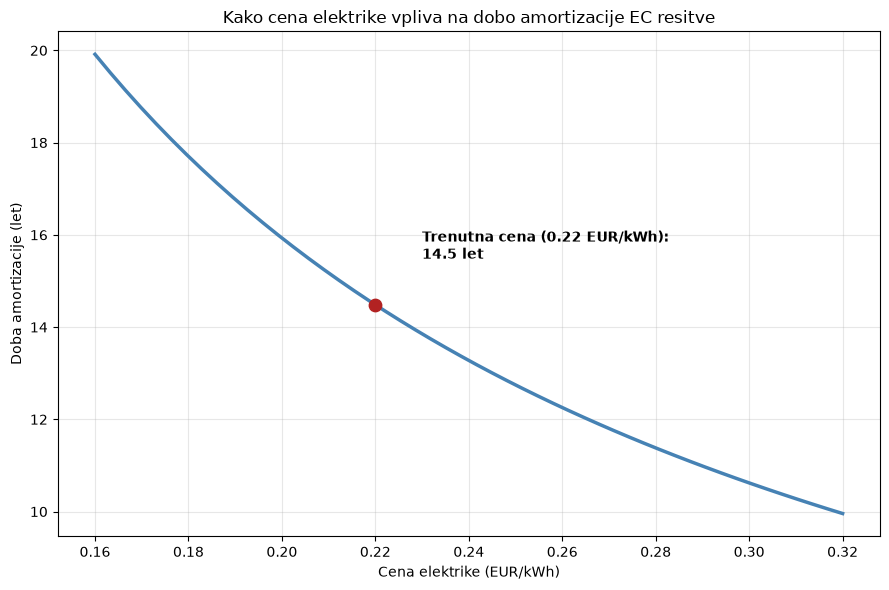

Pri 0.16 EUR/kWh: 19.9 let
Pri 0.32 EUR/kWh: 10.0 let


In [209]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRAF -- kako se DOBA AMORTIZACIJE spreminja z RAZLICNIMI
# (fiksnimi) cenami elektrike, od 0.18 do 0.32 EUR/kWh
# ============================================================

price_range = np.linspace(0.16, 0.32, 50)

# Kolicine (kWh) za oba scenarija -- NEODVISNE od cene, ze izracunane
cooling_kwh_A = baseline_breakdown['cooling_electricity_kwh']
heating_kwh_A = baseline_breakdown['heating_electricity_kwh']

cooling_kwh_B = weighted_breakdown['cooling_electricity_kwh']
heating_kwh_B = weighted_breakdown['heating_electricity_kwh']
window_kwh_B = window_operating_kwh

payback_years_list = []
for price in price_range:
    cost_A = (cooling_kwh_A + heating_kwh_A) * price
    cost_B = (cooling_kwh_B + heating_kwh_B + window_kwh_B) * price
    net_savings = cost_A - cost_B
    payback = total_extra_investment_eur / net_savings if net_savings > 0 else np.nan
    payback_years_list.append(payback)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(price_range, payback_years_list, color="steelblue", linewidth=2.5)

# Oznaci trenutno privzeto ceno
current_price = electricity_price_eur_kwh
current_payback = total_extra_investment_eur / net_annual_savings_eur
ax.scatter([current_price], [current_payback], color="firebrick", zorder=5, s=80)
ax.annotate(f"Trenutna cena ({current_price} EUR/kWh):\n{current_payback:.1f} let",
            xy=(current_price, current_payback),
            xytext=(current_price + 0.01, current_payback + 1),
            fontsize=10, fontweight="bold")

ax.set_xlabel("Cena elektrike (EUR/kWh)")
ax.set_ylabel("Doba amortizacije (let)")
ax.set_title("Kako cena elektrike vpliva na dobo amortizacije EC resitve")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pri {price_range[0]:.2f} EUR/kWh: {payback_years_list[0]:.1f} let")
print(f"Pri {price_range[-1]:.2f} EUR/kWh: {payback_years_list[-1]:.1f} let")

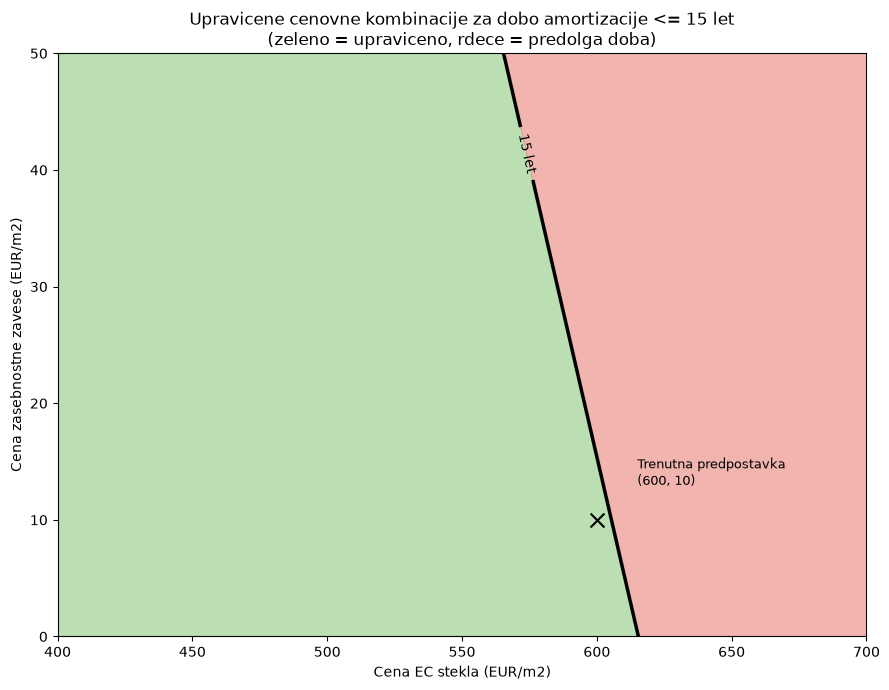

In [210]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRAF -- upravicene cene EC stekla in zavese, za dobo amortizacije <= 8,12,15,18 let
# ============================================================

target_payback_years = 15

# Razpon cen za preizkus
ec_glass_prices = np.linspace(400, 700, 100)      # EUR/m2, EC steklo
curtain_normal_prices = np.linspace(0, 50, 100)    # EUR/m2, zasebnostna zavesa

# Fiksni parametri (iz obstojecega scenarija A -- se ne spreminjajo)
cost_A_fixed = cost_scenario_A_eur_m2   # navadno steklo + blackout zavesa

# Za vsako kombinacijo (EC cena, zavesa cena) izracunaj dobo amortizacije
payback_grid = np.zeros((len(curtain_normal_prices), len(ec_glass_prices)))

for i, curtain_price in enumerate(curtain_normal_prices):
    for j, ec_price in enumerate(ec_glass_prices):
        cost_B_per_m2 = ec_price + curtain_price
        extra_per_m2 = cost_B_per_m2 - cost_A_fixed
        investment = extra_per_m2 * glazing_area + fixed_installation_cost_eur
        if investment > 0 and net_annual_savings_eur > 0:
            payback_grid[i, j] = investment / net_annual_savings_eur
        else:
            payback_grid[i, j] = 0

fig, ax = plt.subplots(figsize=(9, 7))

# Obarvano obmocje: zeleno = znotraj cilja (<=12 let), rdece = izven
contour_fill = ax.contourf(ec_glass_prices, curtain_normal_prices, payback_grid,
                             levels=[0, target_payback_years, payback_grid.max()],
                             colors=["#8FC97F", "#E8827A"], alpha=0.6)

# Mejna crta natancno pri 12 letih
contour_line = ax.contour(ec_glass_prices, curtain_normal_prices, payback_grid,
                            levels=[target_payback_years], colors="black", linewidths=2.5)
ax.clabel(contour_line, fmt=f"{target_payback_years} let", fontsize=10)

# Oznaci trenutno predpostavko
ax.scatter([cost_spd_glass_eur_m2], [curtain_normal_eur_m2], color="black", zorder=5, s=100, marker="x")
ax.annotate(f"Trenutna predpostavka\n({cost_spd_glass_eur_m2}, {curtain_normal_eur_m2})",
            xy=(cost_spd_glass_eur_m2, curtain_normal_eur_m2),
            xytext=(cost_spd_glass_eur_m2+15, curtain_normal_eur_m2+3), fontsize=9)

ax.set_xlabel("Cena EC stekla (EUR/m2)")
ax.set_ylabel("Cena zasebnostne zavese (EUR/m2)")
ax.set_title(f"Upravicene cenovne kombinacije za dobo amortizacije <= {target_payback_years} let\n(zeleno = upraviceno, rdece = predolga doba)")
plt.tight_layout()
plt.show()

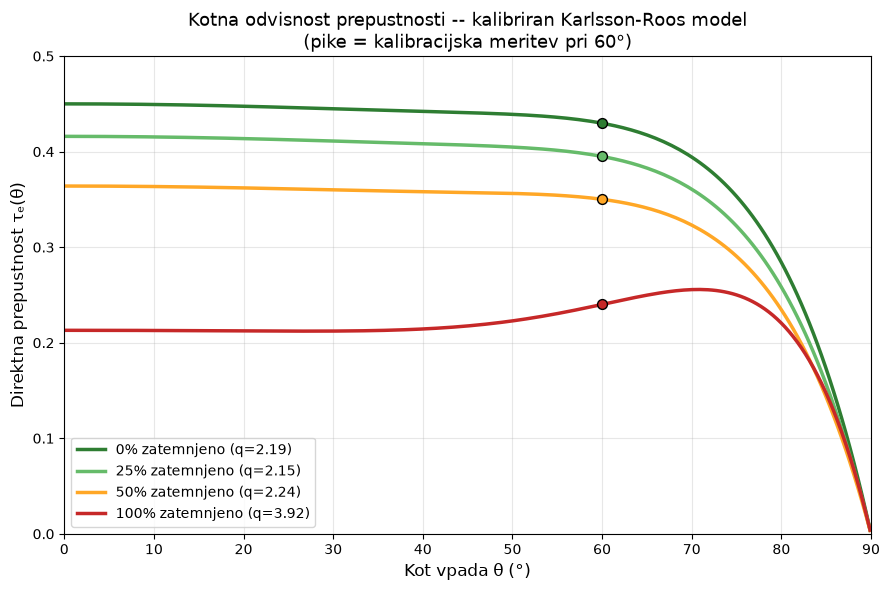

In [211]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRAF 1 -- Kotna krivulja prepustnosti tau_e(theta) za vsa 4 stanja
# ============================================================

theta_range = np.linspace(0, 89.9, 200)
colors = {0: "#2E7D32", 25: "#66BB6A", 50: "#FFA726", 100: "#C62828"}

fig, ax = plt.subplots(figsize=(9, 6))
for state in [0, 25, 50, 100]:
    tau_curve = [karlsson_roos_tau(t, tau_e_0[state], q_guess[state], p) for t in theta_range]
    ax.plot(theta_range, tau_curve, label=f"{state}% zatemnjeno (q={q_guess[state]})",
            color=colors[state], linewidth=2.5)
    # oznaci tocko meritve pri 60 stopinj
    tau_at_60 = karlsson_roos_tau(60, tau_e_0[state], q_guess[state], p)
    ax.scatter([60], [tau_at_60], color=colors[state], zorder=5, s=50, edgecolor="black")

ax.set_xlabel("Kot vpada θ (°)", fontsize=12)
ax.set_ylabel("Direktna prepustnost τₑ(θ)", fontsize=12)
ax.set_title("Kotna odvisnost prepustnosti -- kalibriran Karlsson-Roos model\n(pike = kalibracijska meritev pri 60°)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 90)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.savefig("graf1_tau_theta.png", dpi=300, bbox_inches="tight")
plt.show()

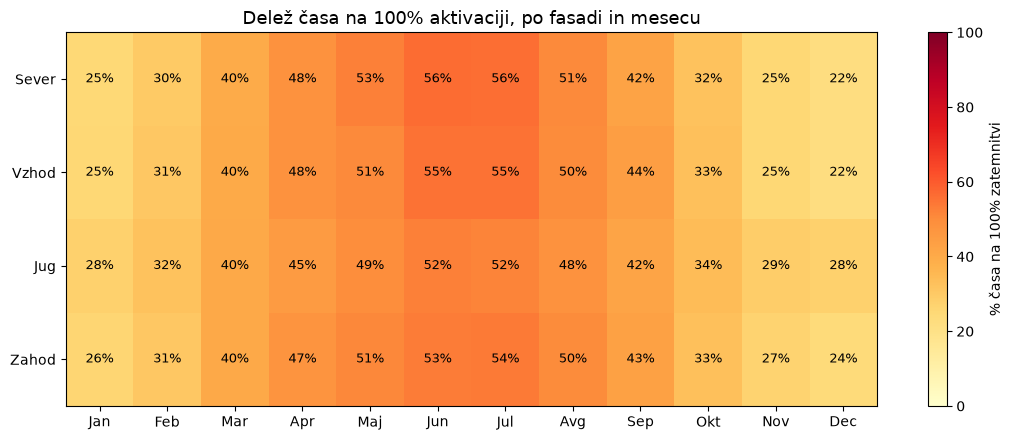

In [212]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# GRAF 4 -- Heatmap: delez casa na 100% aktivaciji, po fasadi in mesecu
# ============================================================

months_order = list(range(1, 13))
month_names = ["Jan","Feb","Mar","Apr","Maj","Jun","Jul","Avg","Sep","Okt","Nov","Dec"]
facades_order = ["North", "East", "South", "West"]

heatmap_data = np.zeros((len(facades_order), 12))

for i, facade in enumerate(facades_order):
    schedule = facade_state_schedule[facade]
    for j, month in enumerate(months_order):
        month_mask = (epw_data.index.month == month)
        pct_100 = (schedule[month_mask] == 100).mean() * 100
        heatmap_data[i, j] = pct_100

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(heatmap_data, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_yticks(range(4))
ax.set_yticklabels(["Sever", "Vzhod", "Jug", "Zahod"])

for i in range(4):
    for j in range(12):
        ax.text(j, i, f"{heatmap_data[i,j]:.0f}%", ha="center", va="center",
                 color="black" if heatmap_data[i,j] < 60 else "white", fontsize=9)

ax.set_title("Delež časa na 100% aktivaciji, po fasadi in mesecu", fontsize=13)
cbar = fig.colorbar(im, ax=ax, label="% časa na 100% zatemnitvi")
plt.tight_layout()
plt.savefig("graf4_heatmap_aktivacija.png", dpi=300, bbox_inches="tight")
plt.show()

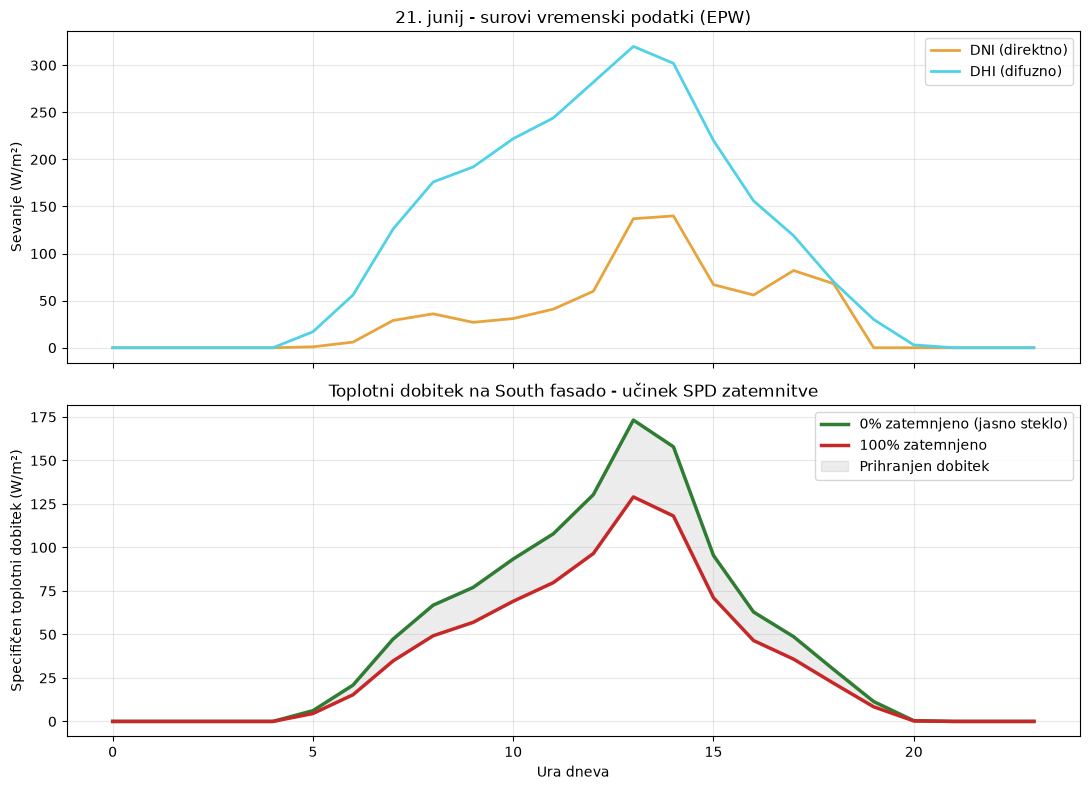

In [214]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# GRAF -- "Anatomija" enega dne (21. junij) -- direktno/difuzno
# sevanje in toplotni dobitek pri 0% proti 100% zatemnitvi
# ============================================================

day_mask = (epw_data.index.month == 6) & (epw_data.index.day == 21)
day_data = epw_data[day_mask]
hours = day_data.index.hour

# Uporabimo JUZNO fasado kot reprezentativen primer
facade = "South"
dni_day = day_data['dni']
dhi_day = day_data['dhi']

q_sol_0 = q_sol_results[0][facade][day_mask]
q_sol_100 = q_sol_results[100][facade][day_mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Zgornji graf -- surovo sevanje
ax1.plot(hours, dni_day, label="DNI (direktno)", color="#E8A33D", linewidth=2)
ax1.plot(hours, dhi_day, label="DHI (difuzno)", color="#4FD1E8", linewidth=2)
ax1.set_ylabel("Sevanje (W/m²)")
ax1.set_title("21. junij - surovi vremenski podatki (EPW)")
ax1.legend()
ax1.grid(alpha=0.3)

# Spodnji graf -- specificen toplotni dobitek, 0% proti 100%
ax2.plot(hours, q_sol_0, label="0% zatemnjeno (jasno steklo)", color="#2E7D32", linewidth=2.5)
ax2.plot(hours, q_sol_100, label="100% zatemnjeno", color="#C62828", linewidth=2.5)
ax2.fill_between(hours, q_sol_0, q_sol_100, alpha=0.15, color="gray", label="Prihranjen dobitek")
ax2.set_xlabel("Ura dneva")
ax2.set_ylabel("Specifičen toplotni dobitek (W/m²)")
ax2.set_title(f"Toplotni dobitek na {facade} fasado - učinek SPD zatemnitve")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graf_dan_21junij.png", dpi=300, bbox_inches="tight")
plt.show()